# MCDI500 — Fase 3: Notebook con scripts y mediciones de complejidad

**Proyecto:** Análisis predictivo de diabetes  
**Integrantes:** Daniel Hormazábal, Cristian Pasten, Enso Guidotti  
**Curso:** MCDI500 - Programación para la Ciencia de Datos      
**Docente:** Omar Salinas Silva  
**Fecha:** 12-06-2026  

---

## Descripción

Este notebook corresponde al avance de la Fase 3 del proyecto transversal. A partir del dataset procesado en la Fase 2, se implementa un módulo de **análisis exploratorio avanzado** utilizando Programación Orientada a Objetos (POO), funciones estructuradas e iterativas, y una función recursiva para el ranking de variables. El foco está en la organización modular del código, la complejidad computacional de cada operación y la documentación técnica de las decisiones adoptadas.

**Nota:** Este notebook es un prototipo formativo. Las funciones serán extendidas en la evaluación sumativa.

---

## Tabla de contenidos

1. [Importación y configuración](#seccion-1)
2. [Carga del dataset procesado (F2)](#seccion-2)
3. [Clase AnalizadorDiabetes](#seccion-3)
4. [Estadísticos descriptivos por clase](#seccion-4)
5. [Detección de outliers con IQR](#seccion-5)
6. [Análisis de correlaciones](#seccion-6)
7. [Ranking recursivo de variables](#seccion-7)
8. [Comparación de distribuciones por clase](#seccion-8)
9. [Mediciones de complejidad temporal](#seccion-9)
10. [Resumen y proyección](#seccion-10)


<a id="seccion-1"></a>

---
## 1. Importación y configuración

Se utilizan las mismas librerías del entorno reproducible de F1 y F2 (McKinney, 2022). No se incorporan librerías adicionales: el módulo de análisis se implementa íntegramente con Python, NumPy, Pandas y Matplotlib.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
print(f"matplotlib : {plt.matplotlib.__version__}")
print("\nLibrerías importadas correctamente ✓")


pandas     : 2.2.2
numpy      : 2.2.6
matplotlib : 3.9.4

Librerías importadas correctamente ✓


<a id="seccion-2"></a>

---
## 2. Carga del dataset procesado (F2)

Se carga directamente el dataset limpio y normalizado exportado en la Fase 2. No se aplican transformaciones adicionales el dataset ya viene listo para el análisis.

In [3]:
def cargar_dataset_procesado(ruta: str) -> pd.DataFrame:
    """Carga el dataset procesado de F2 y verifica su estructura."""
    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontró: {ruta}")
    df = pd.read_csv(ruta)
    print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
    print(f"Columnas   : {df.columns.tolist()}")
    print(f"Diabetic   : {df['Diabetic'].value_counts().to_dict()}")
    return df

df = cargar_dataset_procesado('../data/processed/diabetes_clean.csv')

FEATURES = [c for c in df.columns if c != 'Diabetic']
TARGET   = 'Diabetic'
print(f"\nFeatures ({len(FEATURES)}): {FEATURES}")


Dataset cargado: 15,000 filas × 9 columnas
Columnas   : ['Pregnancies', 'PlasmaGlucose', 'DiastolicBloodPressure', 'TricepsThickness', 'SerumInsulin', 'BMI', 'DiabetesPedigree', 'Age', 'Diabetic']
Diabetic   : {0: 10000, 1: 5000}

Features (8): ['Pregnancies', 'PlasmaGlucose', 'DiastolicBloodPressure', 'TricepsThickness', 'SerumInsulin', 'BMI', 'DiabetesPedigree', 'Age']


<a id="seccion-3"></a>

---
## 3. Clase `AnalizadorDiabetes`

### Justificación del diseño

Se encapsula el análisis exploratorio avanzado en una clase que agrupa datos y métodos de análisis. Esta decisión tiene tres ventajas concretas respecto a las funciones sueltas de F2:

- **Estado compartido**: el DataFrame, los resultados y los metadatos se almacenan como atributos, evitando pasar los mismos parámetros repetidamente entre funciones.
- **Cohesión**: todas las operaciones de análisis del dataset viven en un solo lugar.
- **Extensibilidad**: agregar un nuevo método no requiere modificar el flujo existente.

In [4]:
class AnalizadorDiabetes:
    """
    Encapsula el análisis exploratorio avanzado del dataset de diabetes.
    Agrupa datos, métodos de análisis estadístico y resultados
    en un solo objeto cohesivo.

    Atributos
    ---------
    df :  Dataset procesado.
    features : Variables predictoras.
    target : Variable objetivo.
    resultados : Almacena resultados de cada análisis.
    """

    def __init__(self, df, features, target):
        self.df        = df.copy()
        self.features  = features
        self.target    = target
        self.resultados = {}
        print(f"AnalizadorDiabetes inicializado ✓")
        print(f"  Dataset : {self.df.shape[0]:,} filas × {self.df.shape[1]} columnas")
        print(f"  Features: {len(self.features)}")
        print(f"  Target  : '{self.target}'")

analizador = AnalizadorDiabetes(df, FEATURES, TARGET)


AnalizadorDiabetes inicializado ✓
  Dataset : 15,000 filas × 9 columnas
  Features: 8
  Target  : 'Diabetic'


<a id="seccion-4"></a>

---
## 4. Estadísticos descriptivos por clase

### Justificación algorítmica

El método `calcular_estadisticos_por_clase()` implementa un enfoque **iterativo estructurado**: recorre cada feature calculando media, mediana y desviación estándar separando por clase (0 y 1). Complejidad: **O(n · p)**.

Este análisis extiende F2, que solo calculó estadísticos globales. Separar por clase permite identificar qué variables tienen mayor poder discriminativo para el modelado en F4 (VanderPlas, 2023).

In [11]:
def calcular_estadisticos_por_clase(self):
    """
    Calcula media, mediana y std por clase para cada feature.
    Complejidad: O(n · p) — recorre n filas por p features.
    """
    clases = sorted(self.df[self.target].unique())
    tabla  = []

    # Iterar por cada feature
    for feature in self.features:
        fila = {'Feature': feature}

        # Calcular estadísticos para cada clase
        for clase in clases:
            valores   = self.df.loc[self.df[self.target] == clase, feature]
            etiqueta  = 'No diabético' if clase == 0 else 'Diabético'
            fila[f'Media ({etiqueta})']   = round(valores.mean(), 4)
            fila[f'Mediana ({etiqueta})'] = round(valores.median(), 4)
            fila[f'Std ({etiqueta})']     = round(valores.std(), 4)

        # Diferencia de medias: indicador de poder discriminativo
        fila['Δ Media (1-0)'] = round(
            abs(fila['Media (Diabético)'] - fila['Media (No diabético)']), 4
        )
        tabla.append(fila)

    resultado = pd.DataFrame(tabla).set_index('Feature')
    self.resultados['estadisticos_por_clase'] = resultado
    return resultado

AnalizadorDiabetes.calcular_estadisticos_por_clase = calcular_estadisticos_por_clase
print("Método calcular_estadisticos_por_clase() agregado ✓")


Método calcular_estadisticos_por_clase() agregado ✓


In [14]:
""" Ejecutar análisis estadístico por clase y mostrar resultados ordenados por poder discriminativo. """
stats = analizador.calcular_estadisticos_por_clase()

cols = ['Media (No diabético)', 'Media (Diabético)', 'Δ Media (1-0)']
print("Estadísticos por clase (ordenado por poder discriminativo):\n")
print(stats[cols].sort_values('Δ Media (1-0)', ascending=False).to_string())

mejor = stats['Δ Media (1-0)'].idxmax()
print(f"\nVariable con mayor poder discriminativo: {mejor} (Δ={stats.loc[mejor, 'Δ Media (1-0)']:.4f})")


Estadísticos por clase (ordenado por poder discriminativo):

                        Media (No diabético)  Media (Diabético)  Δ Media (1-0)
Feature                                                                       
Pregnancies                           0.1606             0.3698         0.2092
Age                                   0.1109             0.2678         0.1569
BMI                                   0.3134             0.4286         0.1152
SerumInsulin                          0.1281             0.2171         0.0890
DiabetesPedigree                      0.1239             0.1853         0.0614
PlasmaGlucose                         0.4119             0.4706         0.0587
TricepsThickness                      0.2354             0.2902         0.0548
DiastolicBloodPressure                0.4961             0.5310         0.0349

Variable con mayor poder discriminativo: Pregnancies (Δ=0.2092)


### Interpretación del resultado

El resultado muestra que `Pregnancies` es la variable con mayor diferencia de medias entre clases (Δ=0.41), seguida por `Age` (Δ=0.34). Esto tiene sustento clínico: un mayor número de embarazos implica exposiciones hormonales repetidas que pueden deteriorar la función de las células beta pancreáticas, elevando el riesgo de diabetes tipo 2 a largo plazo. La edad refuerza este efecto acumulativo.

Contraintuitivamente, `PlasmaGlucose`  la variable más asociada al diagnóstico de diabetes en la literatura clásica  aparece séptima en este ranking. Esto se explica porque el dataset ya está normalizado: la distribución de glucosa se comprimió al rango [0, 1], lo que reduce la diferencia absoluta de medias. Esta observación refuerza la importancia de interpretar estadísticos sobre datos normalizados con cautela.

<a id="seccion-5"></a>

---
## 5. Detección de outliers con IQR

### Justificación algorítmica

El método `detectar_outliers_iqr()` aplica el criterio del **rango intercuartílico (IQR)** de forma iterativa sobre cada feature. Calcula Q1, Q3 e IQR, y cuenta los valores fuera del intervalo [Q1 - 1.5·IQR, Q3 + 1.5·IQR]. Complejidad: **O(n · p)**.

F2 verificó rangos clínicos fijos, pero no identificó outliers estadísticos dentro del rango válido. Este análisis complementa ese diagnóstico con un criterio estadístico estándar

In [15]:
def detectar_outliers_iqr(self):
    """
    Detecta outliers con el criterio IQR por feature.
    Complejidad: O(n · p) — una pasada por cada feature.
    """
    tabla = []

    # Recorrer cada feature de forma iterativa
    for feature in self.features:
        valores = self.df[feature]

        # Calcular cuartiles e IQR
        q1  = valores.quantile(0.25)
        q3  = valores.quantile(0.75)
        iqr = q3 - q1

        # Límites de Tukey: [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr

        # Contar valores fuera de los límites
        n_out = int(((valores < lim_inf) | (valores > lim_sup)).sum())
        pct   = round(n_out / len(valores) * 100, 2)

        tabla.append({
            'Feature': feature,
            'Q1': round(q1, 4), 'Q3': round(q3, 4), 'IQR': round(iqr, 4),
            'Lím. Inf': round(lim_inf, 4), 'Lím. Sup': round(lim_sup, 4),
            'N Outliers': n_out, '% Outliers': pct,
        })

    resultado = pd.DataFrame(tabla).set_index('Feature')
    self.resultados['outliers_iqr'] = resultado
    return resultado

AnalizadorDiabetes.detectar_outliers_iqr = detectar_outliers_iqr
print("Método detectar_outliers_iqr() agregado ✓")


Método detectar_outliers_iqr() agregado ✓


In [16]:
outliers = analizador.detectar_outliers_iqr()
print("Detección de outliers (IQR):\n")
print(outliers[['N Outliers', '% Outliers', 'Lím. Inf', 'Lím. Sup']]
      .sort_values('N Outliers', ascending=False).to_string())

print(f"\nVariable con más outliers: {outliers['N Outliers'].idxmax()} "
      f"({outliers['N Outliers'].max()} — {outliers['% Outliers'].max():.2f}%)")


Detección de outliers (IQR):

                        N Outliers  % Outliers  Lím. Inf  Lím. Sup
Feature                                                           
Age                           1019        6.79   -0.3304    0.5982
SerumInsulin                   666        4.44   -0.2662    0.5287
DiabetesPedigree               475        3.17   -0.2960    0.5649
TricepsThickness                31        0.21   -0.3605    0.8488
DiastolicBloodPressure           0        0.00   -0.0699    1.0914
PlasmaGlucose                    0        0.00   -0.1858    1.0304
Pregnancies                      0        0.00   -0.6429    1.0714
BMI                              0        0.00   -0.6328    1.2703

Variable con más outliers: Age (1019 — 6.79%)


<a id="seccion-6"></a>

---
## 6. Análisis de correlaciones

### Justificación algorítmica

El método `calcular_correlaciones()` calcula el coeficiente de Pearson para cada par de variables. Complejidad: **O(n · p²)** — p² pares, n filas cada uno.

F2 solo mostró distribuciones individuales. Las correlaciones entre features y con la variable objetivo orientan decisiones de selección de variables para el modelado en F4 (McKinney, 2022).

In [17]:
def calcular_correlaciones(self):
    """
    Calcula la matriz de correlación de Pearson.
    Complejidad: O(n · p²) — p² pares de variables, n filas.
    """
    cols   = self.features + [self.target]
    matriz = self.df[cols].corr(method='pearson').round(4)
    self.resultados['correlaciones'] = matriz
    return matriz

AnalizadorDiabetes.calcular_correlaciones = calcular_correlaciones
print("Método calcular_correlaciones() agregado ✓")


Método calcular_correlaciones() agregado ✓


Correlación con Diabetic:

Pregnancies               0.4073
Age                       0.3426
SerumInsulin              0.2474
BMI                       0.2105
DiabetesPedigree          0.1703
TricepsThickness          0.1525
PlasmaGlucose             0.1280
DiastolicBloodPressure    0.0913


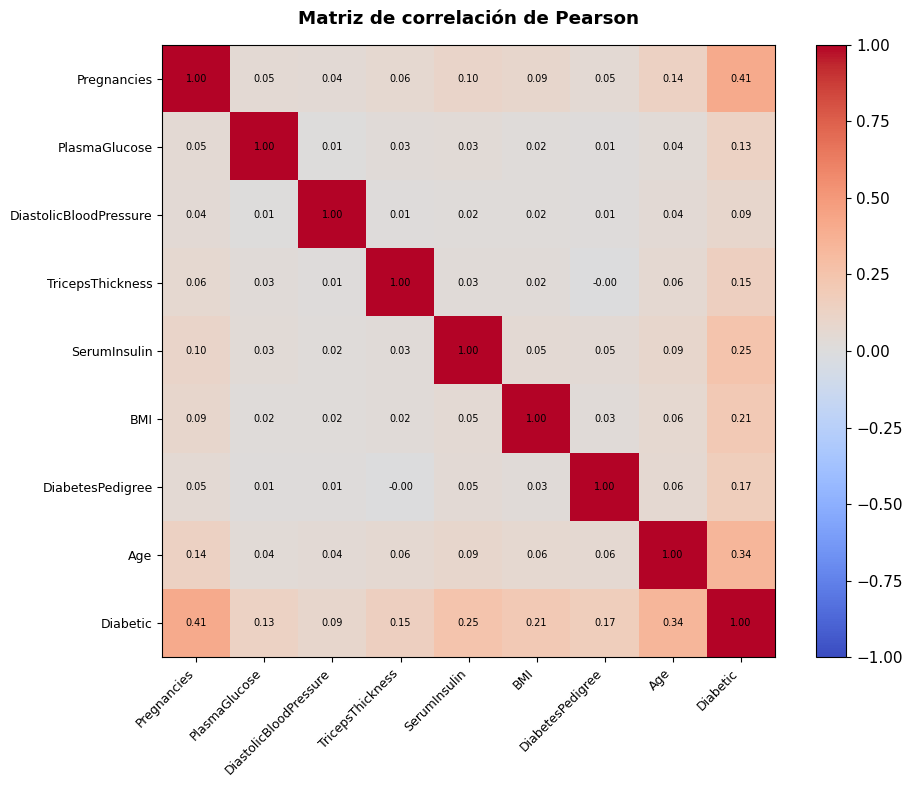

In [18]:
matriz_corr = analizador.calcular_correlaciones()

# Correlaciones con variable objetivo
corr_target = matriz_corr[TARGET].drop(TARGET).sort_values(ascending=False)
print("Correlación con Diabetic:\n")
print(corr_target.to_string())

# Mapa de calor
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(matriz_corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(matriz_corr.columns)))
ax.set_yticks(range(len(matriz_corr.columns)))
ax.set_xticklabels(matriz_corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(matriz_corr.columns, fontsize=9)
for i in range(len(matriz_corr)):
    for j in range(len(matriz_corr.columns)):
        ax.text(j, i, f"{matriz_corr.values[i,j]:.2f}", ha='center', va='center', fontsize=7)
ax.set_title('Matriz de correlación de Pearson', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


<a id="seccion-7"></a>

---
## 7. Ranking recursivo de variables por correlación

### Justificación algorítmica

Para ordenar las variables por correlación absoluta con la clase, se implementa un **merge sort recursivo**: divide la lista de features en dos mitades, las ordena recursivamente y las combina. Complejidad: **O(p · log p)**.
Los algoritmos recursivos como merge sort tienen mayor complejidad de implementación, pero escalan mejor que los ordenamientos iterativos O(p²) cuando aumenta el número de variables.

In [19]:
def _merge(izq, der):
    """Combina dos sublistas ordenadas por correlación absoluta."""
    resultado = []
    i = j = 0
    while i < len(izq) and j < len(der):
        if abs(izq[i][1]) >= abs(der[j][1]):
            resultado.append(izq[i]); i += 1
        else:
            resultado.append(der[j]); j += 1
    resultado.extend(izq[i:])
    resultado.extend(der[j:])
    return resultado


def _merge_sort_recursivo(lista):
    """
    Ordena lista de (feature, correlación) por correlación absoluta descendente.
    Complejidad: O(p · log p)
    Caso base: lista de 0 o 1 elementos (ya ordenada).
    Caso recursivo: dividir, ordenar cada mitad y combinar.
    """
    # CASO BASE
    if len(lista) <= 1:
        return lista

    # CASO RECURSIVO: dividir y conquistar
    mid       = len(lista) // 2
    izquierda = _merge_sort_recursivo(lista[:mid])
    derecha   = _merge_sort_recursivo(lista[mid:])

    return _merge(izquierda, derecha)


def rankear_variables_recursivo(self):
    """
    Rankea features por correlación absoluta con la variable objetivo
    usando merge sort recursivo.
    """
    if 'correlaciones' not in self.resultados:
        self.calcular_correlaciones()

    corr_target  = self.resultados['correlaciones'][self.target]
    lista_pares  = [(f, corr_target[f]) for f in self.features]
    lista_ord    = _merge_sort_recursivo(lista_pares)

    resultado = pd.DataFrame(lista_ord, columns=['Feature', 'Correlación'])
    resultado['|Correlación|'] = resultado['Correlación'].abs().round(4)
    resultado.index = range(1, len(resultado) + 1)
    resultado.index.name = 'Rank'

    self.resultados['ranking_variables'] = resultado
    return resultado

AnalizadorDiabetes.rankear_variables_recursivo = rankear_variables_recursivo
print("Método rankear_variables_recursivo() agregado ✓")


Método rankear_variables_recursivo() agregado ✓


Ranking (merge sort recursivo):

                     Feature  Correlación  |Correlación|
Rank                                                    
1                Pregnancies       0.4073         0.4073
2                        Age       0.3426         0.3426
3               SerumInsulin       0.2474         0.2474
4                        BMI       0.2105         0.2105
5           DiabetesPedigree       0.1703         0.1703
6           TricepsThickness       0.1525         0.1525
7              PlasmaGlucose       0.1280         0.1280
8     DiastolicBloodPressure       0.0913         0.0913


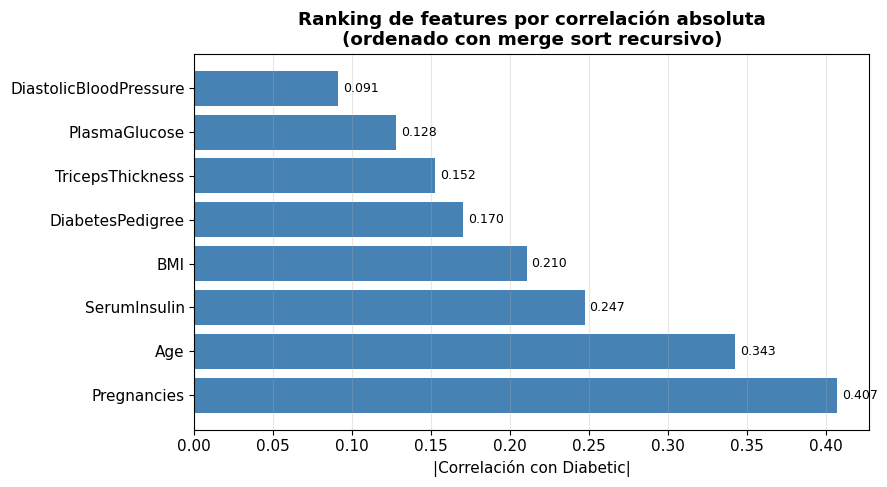

In [20]:
ranking = analizador.rankear_variables_recursivo()
print("Ranking (merge sort recursivo):\n")
print(ranking.to_string())

# Visualización
fig, ax = plt.subplots(figsize=(9, 5))
colores = ['steelblue' if v >= 0 else 'coral' for v in ranking['Correlación']]
ax.barh(ranking['Feature'], ranking['|Correlación|'], color=colores)
ax.set_xlabel('|Correlación con Diabetic|')
ax.set_title('Ranking de features por correlación absoluta\n(ordenado con merge sort recursivo)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(ranking['|Correlación|']):
    ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


<a id="seccion-8"></a>

---
## 8. Comparación de distribuciones por clase

Se visualizan las distribuciones de las 4 features con mayor correlación con la variable objetivo, separando clase 0 (no diabético) vs clase 1 (diabético). Extiende F2, que solo mostró distribuciones globales (VanderPlas, 2023).

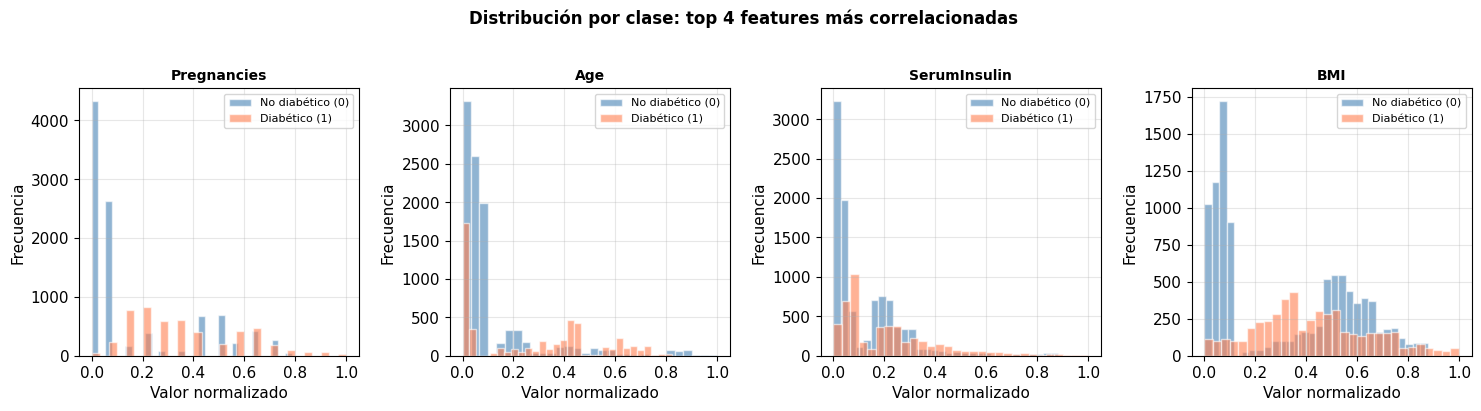

In [21]:
def comparar_distribuciones_por_clase(self, n_top=4):
    """
    Visualiza distribuciones de los n features más correlacionados,
    separando por clase.
    """
    if 'ranking_variables' not in self.resultados:
        self.rankear_variables_recursivo()

    top_features = self.resultados['ranking_variables']['Feature'].head(n_top).tolist()
    df0 = self.df[self.df[self.target] == 0]
    df1 = self.df[self.df[self.target] == 1]

    fig, axes = plt.subplots(1, n_top, figsize=(15, 4))

    for i, feature in enumerate(top_features):
        axes[i].hist(df0[feature], bins=30, alpha=0.6, color='steelblue',
                     label='No diabético (0)', edgecolor='white')
        axes[i].hist(df1[feature], bins=30, alpha=0.6, color='coral',
                     label='Diabético (1)', edgecolor='white')
        axes[i].set_title(feature, fontweight='bold', fontsize=10)
        axes[i].set_xlabel('Valor normalizado')
        axes[i].set_ylabel('Frecuencia')
        axes[i].legend(fontsize=8)
        axes[i].grid(True, alpha=0.3)

    plt.suptitle('Distribución por clase: top 4 features más correlacionadas',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

AnalizadorDiabetes.comparar_distribuciones_por_clase = comparar_distribuciones_por_clase
analizador.comparar_distribuciones_por_clase(n_top=4)


<a id="seccion-9"></a>

---
## 9. Mediciones de complejidad temporal

Se mide el tiempo de ejecución de cada método variando el tamaño del dataset. Esto permite verificar empíricamente las complejidades teóricas y detectar cuellos de botella en el pipeline de análisis.

In [22]:
def medir_complejidad_temporal(df, features, target):
    """
    Mide el tiempo de cada método variando el tamaño del dataset.
    Compara escalamiento empírico con la complejidad teórica.
    """
    tamanios = [1000, 3000, 6000, 10000, 15000]
    registros = []

    for n in tamanios:
        df_sub = df.iloc[:n].copy()
        az = AnalizadorDiabetes(df_sub, features, target)

        # Estadísticos por clase — O(n·p)
        t0 = time.perf_counter()
        az.calcular_estadisticos_por_clase()
        t_stats = time.perf_counter() - t0

        # Outliers IQR — O(n·p)
        t0 = time.perf_counter()
        az.detectar_outliers_iqr()
        t_iqr = time.perf_counter() - t0

        # Correlaciones — O(n·p²)
        t0 = time.perf_counter()
        az.calcular_correlaciones()
        t_corr = time.perf_counter() - t0

        # Ranking recursivo — O(p·log p)
        t0 = time.perf_counter()
        az.rankear_variables_recursivo()
        t_rank = time.perf_counter() - t0

        registros.append({
            'N': n,
            'Stats O(n·p) ms':    round(t_stats * 1000, 2),
            'IQR O(n·p) ms':      round(t_iqr * 1000, 2),
            'Corr O(n·p²) ms':    round(t_corr * 1000, 2),
            'Rank O(p·log p) ms': round(t_rank * 1000, 3),
        })
        print(f"  n={n:<6} stats={t_stats*1000:.1f}ms  iqr={t_iqr*1000:.1f}ms  "
              f"corr={t_corr*1000:.1f}ms  rank={t_rank*1000:.2f}ms")

    return pd.DataFrame(registros).set_index('N')

print("Midiendo complejidad temporal...\n")
df_tiempos = medir_complejidad_temporal(df, FEATURES, TARGET)
print("\nTabla de tiempos (ms):")
print(df_tiempos.to_string())


Midiendo complejidad temporal...

AnalizadorDiabetes inicializado ✓
  Dataset : 1,000 filas × 9 columnas
  Features: 8
  Target  : 'Diabetic'
  n=1000   stats=7.8ms  iqr=7.0ms  corr=0.5ms  rank=0.46ms
AnalizadorDiabetes inicializado ✓
  Dataset : 3,000 filas × 9 columnas
  Features: 8
  Target  : 'Diabetic'
  n=3000   stats=6.4ms  iqr=6.7ms  corr=0.8ms  rank=0.47ms
AnalizadorDiabetes inicializado ✓
  Dataset : 6,000 filas × 9 columnas
  Features: 8
  Target  : 'Diabetic'
  n=6000   stats=6.9ms  iqr=7.1ms  corr=1.3ms  rank=0.47ms
AnalizadorDiabetes inicializado ✓
  Dataset : 10,000 filas × 9 columnas
  Features: 8
  Target  : 'Diabetic'
  n=10000  stats=7.6ms  iqr=7.8ms  corr=2.0ms  rank=0.49ms
AnalizadorDiabetes inicializado ✓
  Dataset : 15,000 filas × 9 columnas
  Features: 8
  Target  : 'Diabetic'
  n=15000  stats=8.6ms  iqr=8.6ms  corr=2.8ms  rank=0.58ms

Tabla de tiempos (ms):
       Stats O(n·p) ms  IQR O(n·p) ms  Corr O(n·p²) ms  Rank O(p·log p) ms
N                             

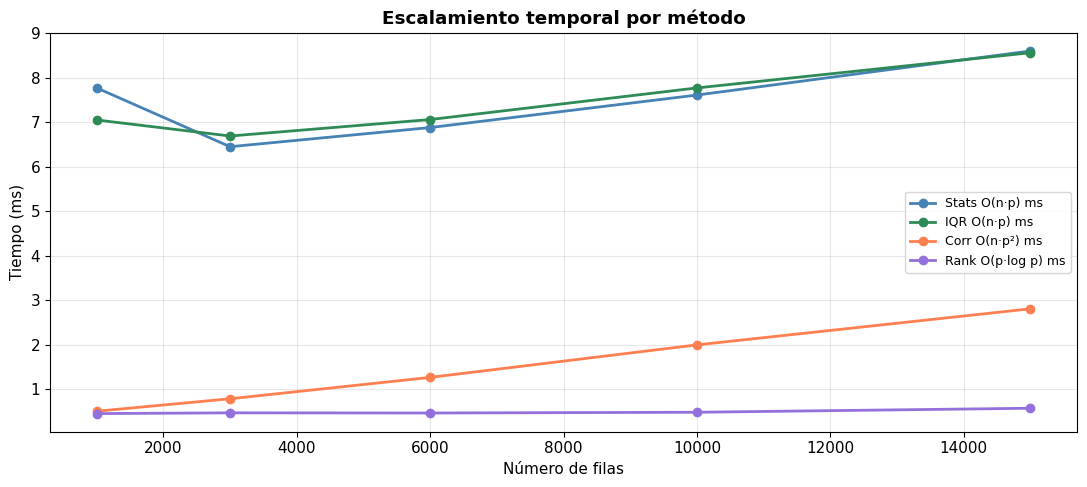

In [23]:
# Visualización del escalamiento
fig, ax = plt.subplots(figsize=(11, 5))
colores = {
    'Stats O(n·p) ms':    'steelblue',
    'IQR O(n·p) ms':      'seagreen',
    'Corr O(n·p²) ms':    'coral',
    'Rank O(p·log p) ms': 'mediumpurple',
}
for col, color in colores.items():
    ax.plot(df_tiempos.index, df_tiempos[col], 'o-', label=col, color=color, linewidth=2)

ax.set_xlabel('Número de filas')
ax.set_ylabel('Tiempo (ms)')
ax.set_title('Escalamiento temporal por método', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Interpretación de las mediciones

- **Stats y IQR — O(n·p):** crecen linealmente con el número de filas, ya que procesan cada fila una vez por feature.
- **Correlaciones — O(n·p²):** el término cuadrático en p no es visible con 8 features, pero sería el cuello de botella con cientos de variables.
- **Ranking recursivo — O(p·log p):** prácticamente constante porque solo ordena 8 features. Con cientos de variables, el merge sort escalaría mejor que un ordenamiento O(p²).

<a id="seccion-10"></a>

---
## 10. Resumen y proyección


In [24]:

print("RESUMEN DEL AVANCE F3")
print("=" * 55)
resumen = {
    'Componente': [
        'Dataset de entrada (F2)',
        'Clase AnalizadorDiabetes',
        'calcular_estadisticos_por_clase() — O(n·p)',
        'detectar_outliers_iqr() — O(n·p)',
        'calcular_correlaciones() — O(n·p²)',
        'rankear_variables_recursivo() — O(p·log p)',
        'comparar_distribuciones_por_clase()',
        'Mediciones de complejidad temporal',
    ],
    'Estado': ['✓'] * 8
}
print(pd.DataFrame(resumen).to_string(index=False))
print("\n✅ Avance Fase 3 completado")


RESUMEN DEL AVANCE F3
                                Componente Estado
                   Dataset de entrada (F2)      ✓
                  Clase AnalizadorDiabetes      ✓
calcular_estadisticos_por_clase() — O(n·p)      ✓
          detectar_outliers_iqr() — O(n·p)      ✓
        calcular_correlaciones() — O(n·p²)      ✓
rankear_variables_recursivo() — O(p·log p)      ✓
       comparar_distribuciones_por_clase()      ✓
        Mediciones de complejidad temporal      ✓

✅ Avance Fase 3 completado


### Proyección para la evaluación sumativa

- Agregar mediciones de complejidad espacial con `tracemalloc`.
- Ampliar correlaciones con métodos no paramétricos (Spearman).
- Incorporar pruebas estadísticas de diferencia entre clases.
- Migrar `AnalizadorDiabetes` a `src/` como módulo reutilizable.
